<a href="https://colab.research.google.com/github/anagwer/roblox/blob/main/Perbandingan_metode_Prediksi_Saham_NFXL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pengumpulan data dari Yahoo Finance**

In [ ]:
!pip install yfinance scikit-learn matplotlib pandas numpy

# **Impor Library dan Unduh Data**

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Unduh data
df = yf.download('NFLX', start='2017-01-01', end='2022-12-31', auto_adjust=True)

# Ratakan MultiIndex kolom
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Simpan kolom penting
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
print("Data awal:", df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

Data awal: (1510, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,12.496,12.819,12.431,12.749,94379000
2017-01-04,12.749,13.017,12.655,12.941,78436000
2017-01-05,12.922,13.275,12.890,13.181,101855000
2017-01-06,13.208,13.388,12.981,13.107,106579000
2017-01-09,13.148,13.199,12.989,13.095,57718000


# **Pra-pemrosesan data**

In [ ]:
# Return & Volatilitas
df['Return'] = df['Close'].pct_change()
df['Volatility_5'] = df['Return'].rolling(5).std()
df['Volatility_10'] = df['Return'].rolling(10).std()

# Moving averages
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_10'] = df['Close'].rolling(10).mean()
df['EMA_5'] = df['Close'].ewm(span=5).mean()
df['EMA_10'] = df['Close'].ewm(span=10).mean()

# RSI manual
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['Close'])

# MACD manual
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast).mean()
    ema_slow = series.ewm(span=slow).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal).mean()
    return macd, signal_line

df['MACD'], df['MACD_signal'] = compute_macd(df['Close'])

# Bollinger Bands
bb_mid = df['Close'].rolling(20).mean()
bb_std = df['Close'].rolling(20).std()
df['BB_upper'] = bb_mid + 2 * bb_std
df['BB_lower'] = bb_mid - 2 * bb_std

# Lag features
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df['Volume_lag1'] = df['Volume'].shift(1)

# Drop NaN
df.dropna(inplace=True)
df.reset_index(inplace=True)

print("Data setelah feature engineering:", df.shape)

Data setelah feature engineering: (1491, 21)


# **PERSIAPKAN DATA UNTUK MODEL**

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    'Open', 'High', 'Low', 'Volume',
    'SMA_5', 'SMA_10', 'EMA_5', 'EMA_10',
    'RSI', 'MACD', 'MACD_signal',
    'BB_upper', 'BB_lower', 'Volatility_5', 'Volatility_10',
    'Close_lag1', 'Close_lag2', 'Volume_lag1'
]

X = df[features]
y = df['Close']

# Scaling untuk model linear & SVR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 80-20
split_idx = int(0.8 * len(X))
X_train = X_scaled[:split_idx]
X_test = X_scaled[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Data mentah untuk tree-based (tidak diskalakan)
X_train_raw = X.iloc[:split_idx].values
X_test_raw = X.iloc[split_idx:].values

print("Split selesai.")
print(f"X_train shape: {X_train.shape}, X_train_raw shape: {X_train_raw.shape}")

Split selesai.
X_train shape: (1192, 18), X_train_raw shape: (1192, 18)


# **Inisialisasi Model**

# **Pelatihan dan Evaluasi Model**

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import time

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "ElasticNet": ElasticNet(max_iter=10000),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')
}

param_grids = {
    "Ridge": {'alpha': [0.01, 0.1, 1, 10]},
    "Lasso": {'alpha': [0.001, 0.01, 0.1, 1]},
    "ElasticNet": {'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.3, 0.5, 0.7]},
    "SVR": {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
}

tree_models = {"RandomForest", "XGBoost"}
results = {}

for model_name, model in models.items():
    print(f"\nMelatih {model_name}...")

    if model_name in tree_models:
        X_tr, X_te = X_train_raw, X_test_raw
    else:
        X_tr, X_te = X_train, X_test

    start_time = time.time()

    if model_name in param_grids:
        grid = GridSearchCV(model, param_grids[model_name], scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
        grid.fit(X_tr, y_train)
        best_model = grid.best_estimator_
        print(f"[{model_name}] Best Params: {grid.best_params_}")
    else:
        best_model = model
        best_model.fit(X_tr, y_train)

    exec_time = time.time() - start_time
    y_pred = best_model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[model_name] = {
        'rmse': rmse,
        'exec_time': exec_time,
        'model': best_model
    }

    print(f"[{model_name}] RMSE: {rmse:.4f}, Execution Time: {exec_time:.4f} s")


Melatih LinearRegression...
[LinearRegression] RMSE: 0.1283, Execution Time: 0.0260 s

Melatih Ridge...
[Ridge] Best Params: {'alpha': 0.01}
[Ridge] RMSE: 0.1860, Execution Time: 2.5055 s

Melatih Lasso...
[Lasso] Best Params: {'alpha': 0.001}
[Lasso] RMSE: 0.3713, Execution Time: 0.3512 s

Melatih ElasticNet...
[ElasticNet] Best Params: {'alpha': 0.01, 'l1_ratio': 0.7}
[ElasticNet] RMSE: 0.6564, Execution Time: 0.2513 s

Melatih SVR...
[SVR] Best Params: {'C': 10, 'gamma': 'auto'}
[SVR] RMSE: 4.5653, Execution Time: 1.1188 s

Melatih RandomForest...
[RandomForest] RMSE: 0.9676, Execution Time: 2.3768 s

Melatih XGBoost...
[XGBoost] RMSE: 1.0921, Execution Time: 0.4616 s


# **Analisis Hasil**


Ringkasan Hasil:
                      rmse exec_time
LinearRegression  0.128314  0.026026
Ridge             0.186007  2.505463
Lasso               0.3713  0.351168
ElasticNet        0.656355  0.251319
SVR               4.565343  1.118769
RandomForest        0.9676  2.376842
XGBoost           1.092138   0.46158


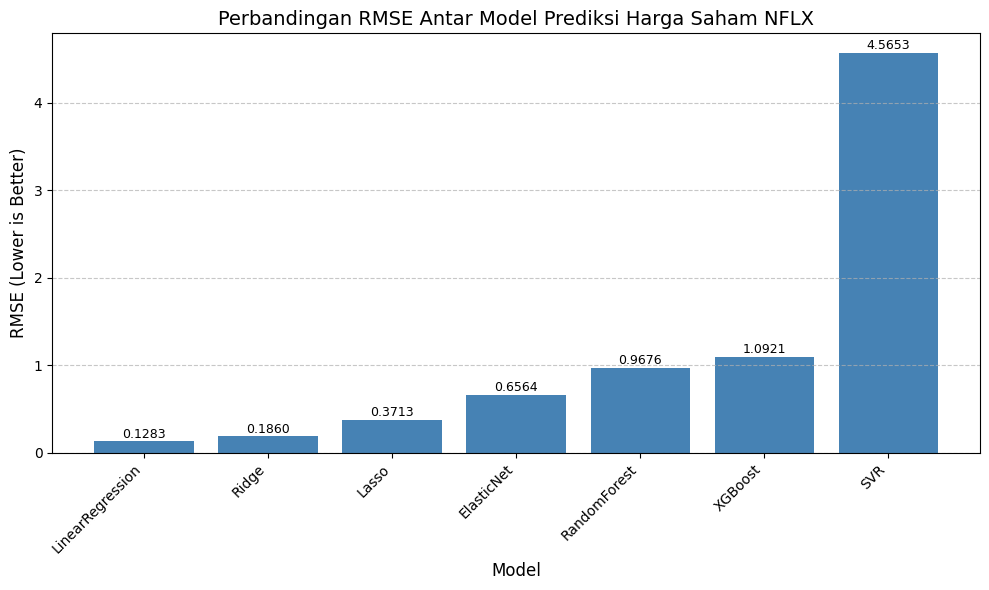

In [ ]:
# Pastikan import pyplot
import matplotlib.pyplot as plt
import pandas as pd

# Ringkasan hasil
result_df = pd.DataFrame(results).T
print("\nRingkasan Hasil:")
print(result_df[['rmse', 'exec_time']].round(4))

# Plot RMSE — urutkan dari terendah ke tertinggi
result_df_sorted = result_df.sort_values('rmse')

plt.figure(figsize=(10, 6))
bars = plt.bar(result_df_sorted.index, result_df_sorted['rmse'], color='steelblue')

# Tambahkan nilai RMSE di atas tiap bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9
    )

plt.title('Perbandingan RMSE Antar Model Prediksi Harga Saham NFLX', fontsize=14)
plt.ylabel('RMSE (Lower is Better)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

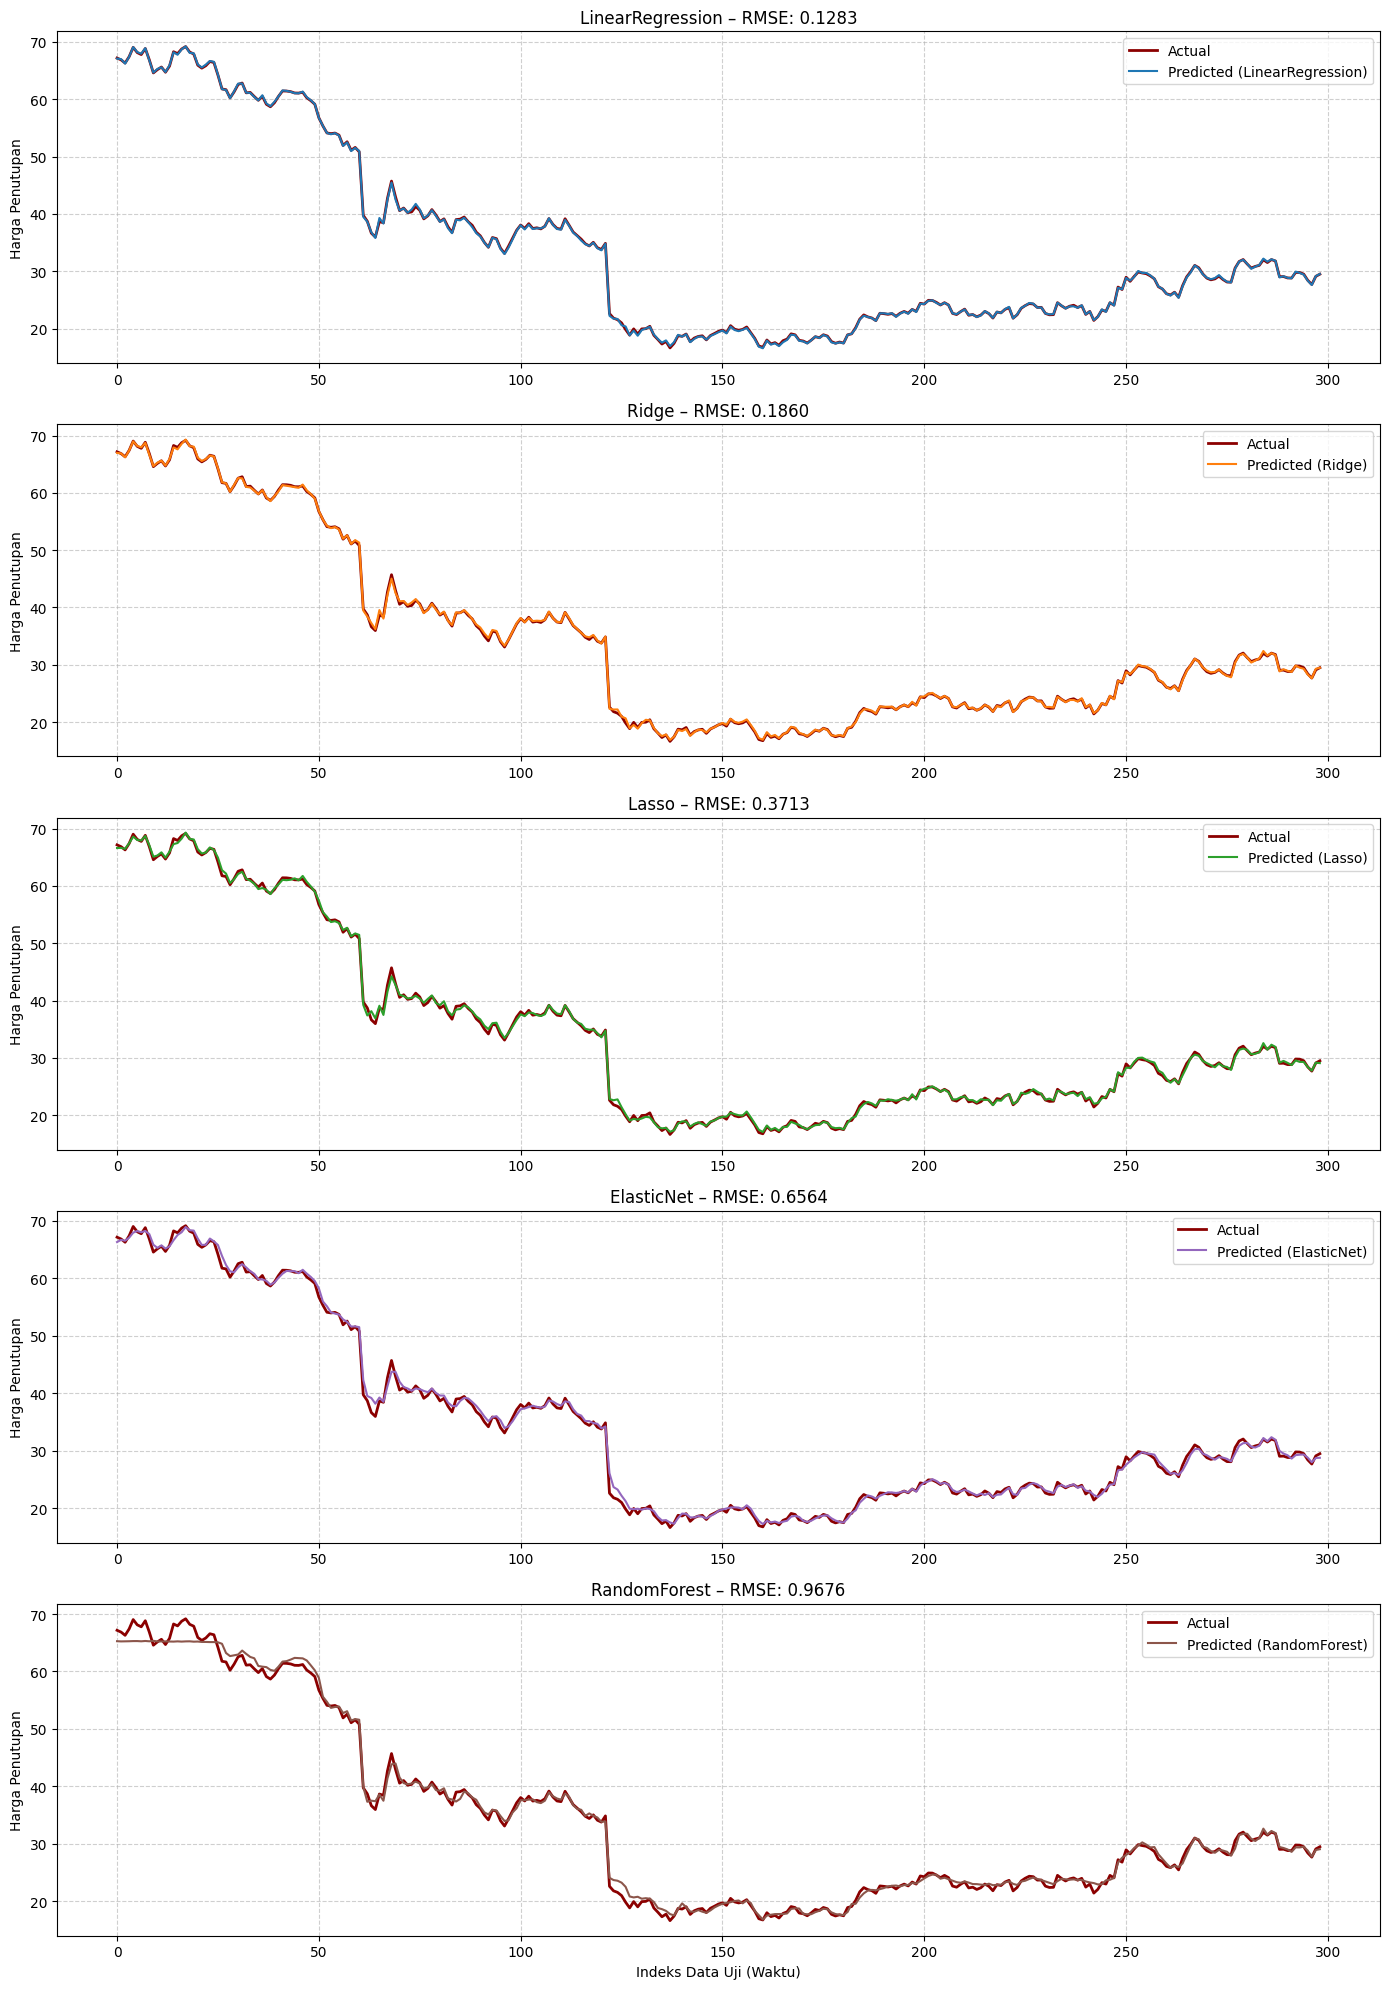

In [ ]:
# %% [code]
import matplotlib.pyplot as plt

# Ambil data aktual
actual = y_test.values

# Urutkan model berdasarkan RMSE, ambil 5 terbaik
models_to_plot = result_df.sort_values('rmse').head(5).index.tolist()

# Warna untuk prediksi tiap model (bisa disesuaikan)
pred_colors = {
    "LinearRegression": "tab:blue",
    "Ridge": "tab:orange",
    "Lasso": "tab:green",
    "ElasticNet": "tab:purple",
    "SVR": "tab:red",
    "RandomForest": "tab:brown",
    "XGBoost": "tab:pink"
}

n_models = len(models_to_plot)
fig, axes = plt.subplots(n_models, 1, figsize=(14, 4 * n_models))

if n_models == 1:
    axes = [axes]

for i, model_name in enumerate(models_to_plot):
    # Pilih data input yang sesuai
    X_input = X_test_raw if model_name in {"RandomForest", "XGBoost"} else X_test
    pred = results[model_name]['model'].predict(X_input)

    # Plot aktual (warna merah tua / hitam)
    axes[i].plot(actual, label='Actual', color='darkred', linewidth=2.0)

    # Plot prediksi (warna sesuai model)
    color = pred_colors.get(model_name, 'steelblue')
    axes[i].plot(pred, label=f'Predicted ({model_name})', color=color, linewidth=1.5)

    # Atur tampilan
    axes[i].set_title(f'{model_name} – RMSE: {results[model_name]["rmse"]:.4f}', fontsize=12)
    axes[i].set_ylabel('Harga Penutupan', fontsize=10)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Indeks Data Uji (Waktu)', fontsize=10)
plt.tight_layout()
plt.show()